# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [7]:
best_Elias27 = {'m': -3.297430763696686, 'c': 316115113583956.4, 'l': 44039.6957302716}
best_AS209 = {'m': -1.3620915465005585, 'c': 4681.0681578390195, 'l': 72454.15132114716}


In [8]:
params =  {'m': -2, 'c': 1e8, 'l': 7e4}


In [9]:
data =  AS209

In [10]:

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Frank Parameters
N = 300

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

dir_fits =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk_fits = disk_name + '_continuum.fits'
fits_file = dir_fits + disk_fits

geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

# Disk

In [11]:
frank2d.process_vis(uvtable)

Setting gridded data...


In [12]:
#print(frank2d.gridded_data['vis'].dtype, type(frank2d.gridded_data['vis']))

In [13]:
best_params = best_AS209

Setting GP Kernel Wendland...
Creating sparse linear system...


--> time kernel = 0.04  min |  2.26 seconds
--> time = 0.04  min |  2.33 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.881751982790494
Final tolerance :  2.881751982790494
.... iteration:  0
                        -> actual tol:  288175198.2790494 vs  2.881751982790494
.... iteration:  1
                        -> actual tol:  26326009.765339244 vs  2.881751982790494
.... iteration:  2
                        -> actual tol:  23214242.49799463 vs  2.881751982790494
.... iteration:  3
                        -> actual tol:  23233630.86969668 vs  2.881751982790494
.... iteration:  4
                        -> actual tol:  23003242.4621651 vs  2.881751982790494
.... iteration:  5
                        -> actual tol:  22241933.701379918 vs  2.881751982790494
.... iteration:  6
                        -> actual tol:  23846750.01607761 vs  2.881751982790494
.... iteration:  7
                        -> actual tol:  24234972.3062802 vs  2.881751982790

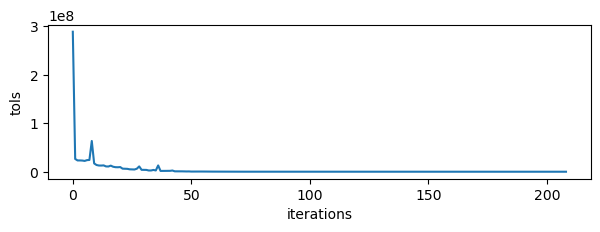

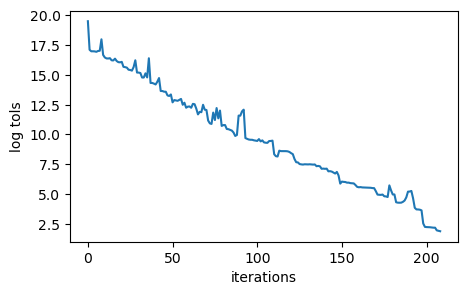

--> time = 0.21  min |  12.79 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   False
Building full visibility model...
--> times building full visibility model = 0.07  min |  4.30 seconds


In [14]:
frank2d.fit(kernel_params = best_params, rtol = 1e-8)

### Plot

In [15]:
Plot_= Plot(frank2d)

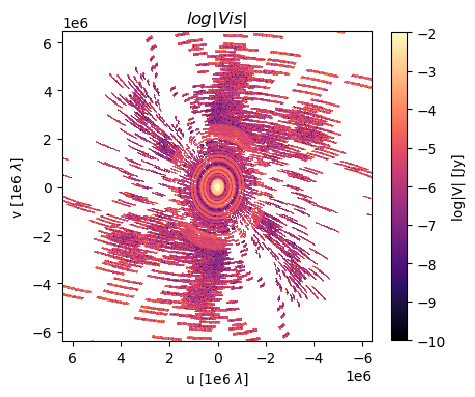

In [16]:
Plot_.visibility(fig_size = 5, kind = 'input')

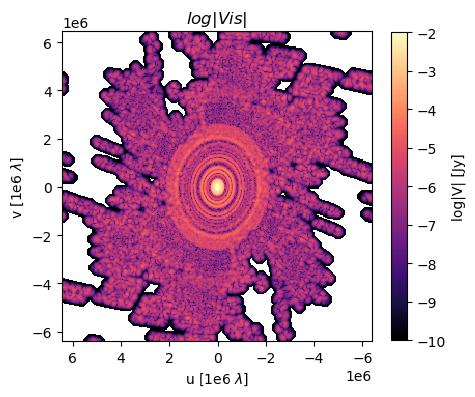

In [17]:
Plot_.visibility(fig_size = 5)

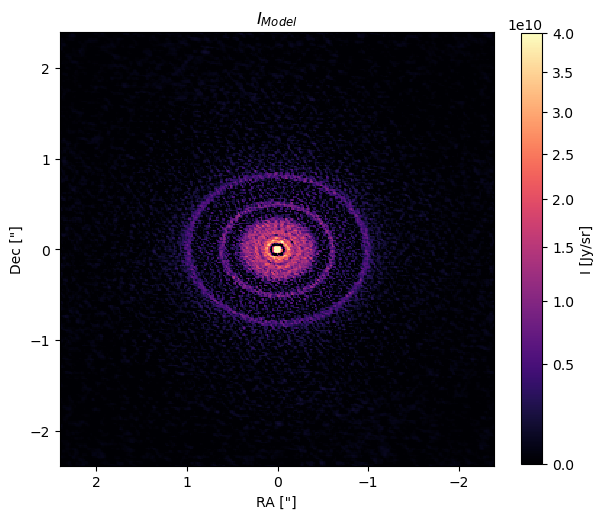

In [18]:
Plot_.intensity(fig_size = 7, vmax = 4e10, gamma = 0.7)

Frank1D profile not set.Using gridded visibilities as input.
Performing 1D Frank fit...

+ $\alpha$ =  1.05  and $w_{smooth}$ =  0.001

+ N =  300  and $R_{max}$ =  None


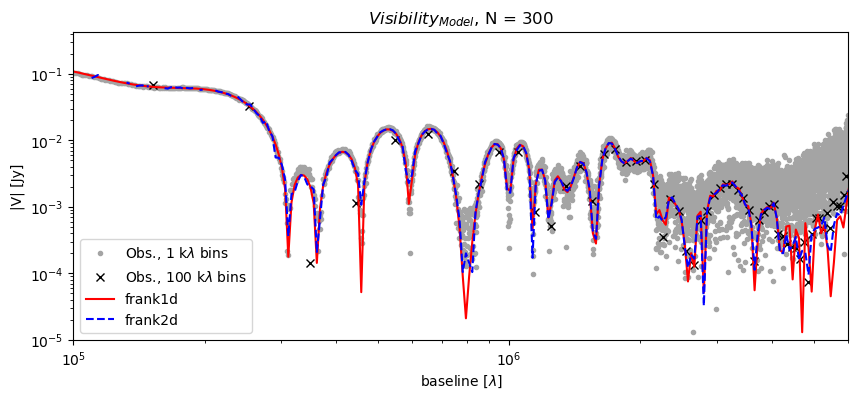

In [19]:
Plot_.visibility_profile(input = uvtable, weighted = True, frank1d = True)

In [20]:
dir_fits =  dir
disk_fits = disk_name + '_continuum.fits'
fits_file = dir_fits + disk_fits

In [21]:
Plot_.set_fits_file(fits_file)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.023 arcsec
-> Final beam to convolve with: 0.030520239838780373 x 0.027986516768390746 arcsec


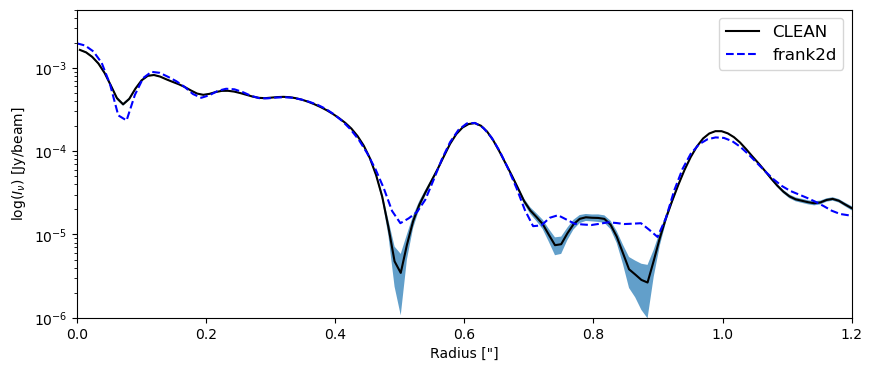

In [22]:
Plot_.intensity_profile(
    clean = True, frank1d = False,
    resol_f2d = 0.023, x_lims = (0, 1.2)
    )

In [23]:
# Frank 1D parameters
n_pts = 300
alpha = 1.05
w_smooth = 1e-4
r_out = rout

sol_f1d = frank2d.frank1d(alpha = alpha, w_smooth = w_smooth, n_pts = n_pts, rout = r_out)

Performing 1D Frank fit...

+ $\alpha$ =  1.05  and $w_{smooth}$ =  0.0001

+ N =  300  and $R_{max}$ =  2.4


In [24]:
Plot_.set_f1d_solution(sol_f1d)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.023 arcsec
-> Final beam to convolve with: 0.030520239838780373 x 0.027986516768390746 arcsec
FWHM for frank1d: 0.0147 arcsec
-> Final beam to convolve with: 0.035275983895799085 x 0.03310823342957785 arcsec


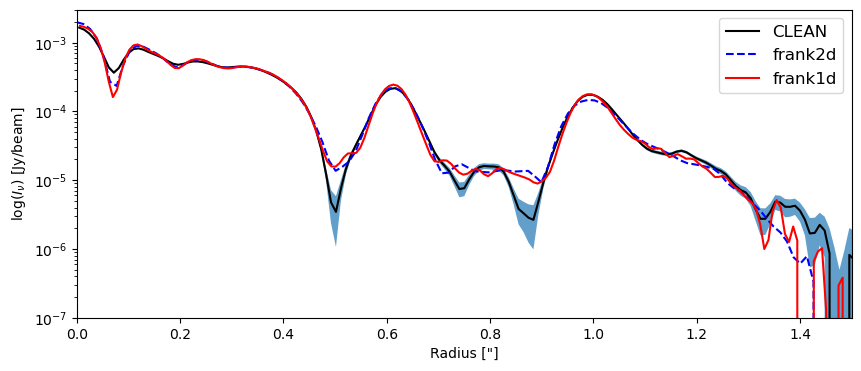

In [28]:
Plot_.intensity_profile(
    clean = True, frank1d = True,
    resol_f2d = 0.023, resol_f1d = 0.0147,
    x_lims = (0, 1.5), y_lims = (1e-7, 3e-3)
    )

### Best

In [18]:
ME = MAPEstimator(frank2d._Rmax,  frank2d._Geometry)
frank2d.set_MAP_estimator(ME)
frank2d.search_MAP()
frank2d.MAP